In [4]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import ttest_ind
from matplotlib.collections import PolyCollection

In [5]:
### Fig.5(B)
data8 = pd.read_pickle('G_ripple_data8.pkl')
data8.head(2)

,WinnerID,AuthorID,delta_C_coauthor,strength
0,W281,C1,-0.031272,3
1,W1010,C2,-0.013791,3


In [6]:
data8['strength_group'] = pd.cut(data8['strength'], bins=[0, 1, 4, data8['strength'].max()+1],labels=['Weak tie', 'Moderate tie', 'Strong tie'],right=True)

In [7]:
results = []
for name, group in data8.groupby("strength_group"):
    d1 = group["delta_C_coauthor"].dropna()  
    mean1 = d1.mean()
    ci95_1 = 1.96 * np.std(d1, ddof=1) / np.sqrt(len(d1))
    results.append({
        "strength_group": name,
        "delta_C_coauthor": mean1,
        "ci95_coauthor": ci95_1})
summary_df = pd.DataFrame(results)
summary_df

/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1767964/2000840348.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in data8.groupby("strength_group"):


,strength_group,delta_C_coauthor,ci95_coauthor
0,Weak tie,0.053780,0.002118
1,Moderate tie,0.049249,0.002520
2,Strong tie,0.046811,0.003371


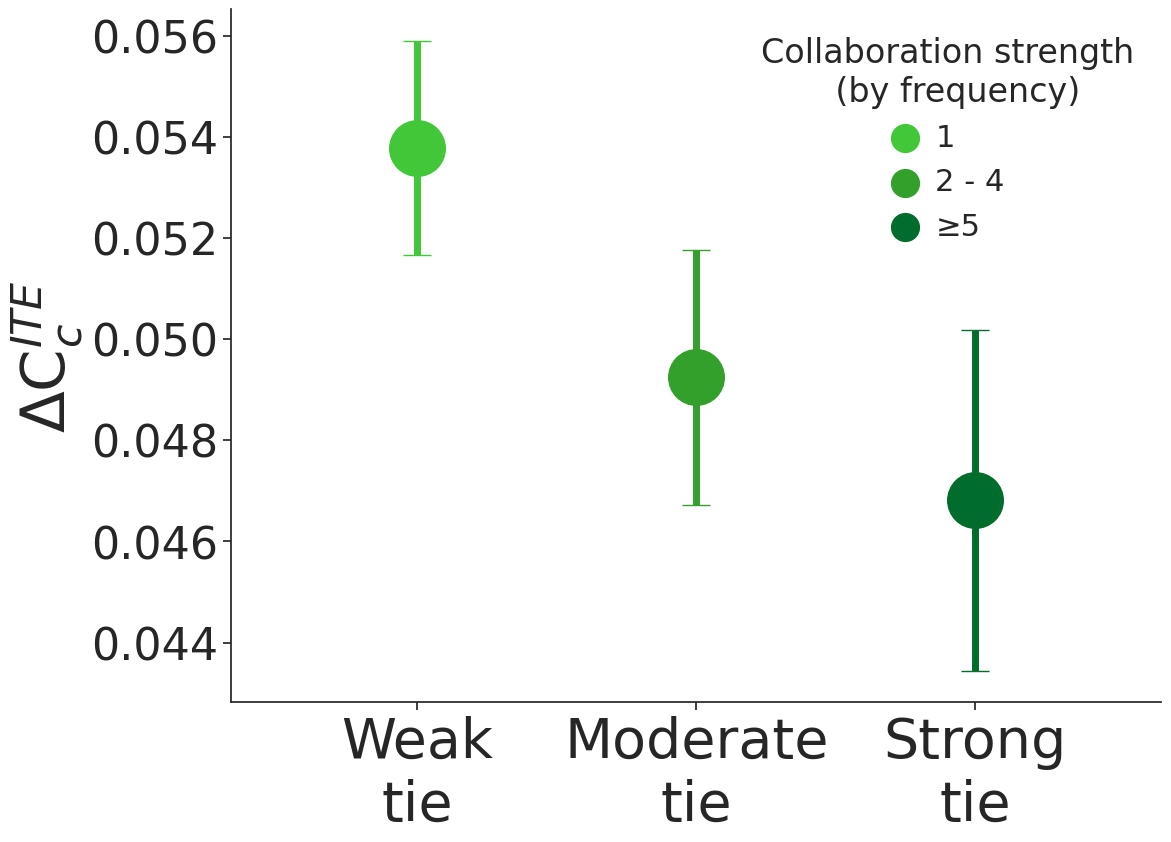

In [8]:
sns.set(font_scale=1.5)
sns.set(style="ticks")
fig, ax = plt.subplots(figsize=(12,9))
##strength1
plt.scatter(0.2, 0.053780, marker='o', s=1600, edgecolors='#41C737', facecolors='#41C737', zorder=0, label='1')
plt.errorbar(0.2, 0.053780, yerr=0.002118, color='#41C737', capsize=10,elinewidth=5)
##strength2
plt.scatter(0.5, 0.049249, marker='o', s=1600, edgecolors='#33A02C', facecolors='#33A02C', zorder=0, label='2 - 4')
plt.errorbar(0.5, 0.049249, yerr=0.002520, color='#33A02C', capsize=10,elinewidth=5)
##strength3
plt.scatter(0.8, 0.046811, marker='o', s=1600, edgecolors='#006D2C', facecolors='#006D2C', zorder=0, label='≥5')
plt.errorbar(0.8, 0.046811, yerr=0.003371, color='#006D2C', capsize=10,elinewidth=5)
plt.ylabel(r"ΔC$^{ITE}_{c}$", fontsize=44)
plt.xticks([0.2, 0.5,0.8], ['Weak\ntie', 'Moderate\ntie','Strong\ntie'], fontsize=40)
plt.yticks(fontsize=32)
plt.xlim(0, 1)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(fontsize=22,frameon=False,loc='upper right',
    title="Collaboration strength\n       (by frequency)",title_fontsize=24,
    scatterpoints=1,    markerscale=0.5,     
    handlelength=1.0,    handletextpad=0.5)
plt.show()

In [9]:
### Fig.5(C)
data20 = pd.read_pickle('G_ripple_data20.pkl')
data20.head(2)

,strength_group,award_year,delta_C_coauthor,group
0,Weak,1969,0.058012,Coauthor
1,Weak,1970,0.188411,Coauthor


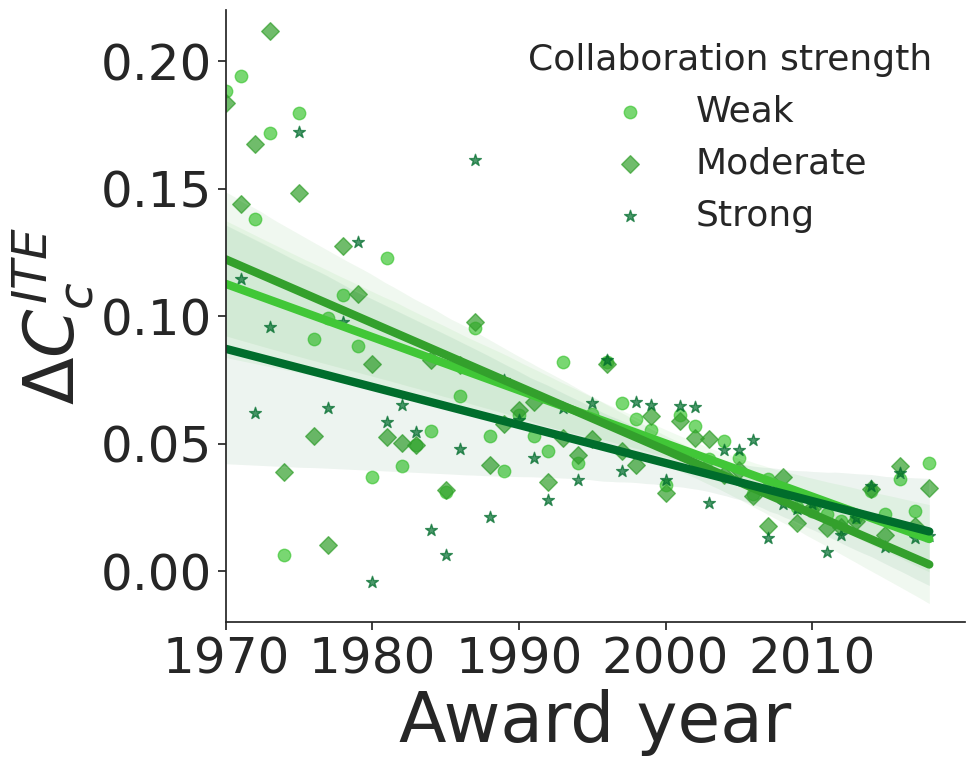

In [10]:
sns.set(style="ticks", font_scale=1.5)
palette = {'Weak': '#41C737','Moderate': '#33A02C','Strong': '#006D2C'}
g = sns.lmplot(data=data20,
    x="award_year",y="delta_C_coauthor",hue="strength_group",         
    ci=95,order=1,height=8,aspect=1,palette=palette,markers=["o", "D", "*"],
    scatter_kws={"s": 80, "alpha": 0.7},line_kws={"linewidth": 6})
for ax in g.axes.flat:
    for coll in ax.collections:
        if isinstance(coll, PolyCollection):
            coll.set_alpha(0.07)
plt.xlabel("Award year", fontsize=50)
plt.ylabel(r"$\Delta C^{ITE}_{c}$", fontsize=50)
plt.xlim(1970, None)
plt.xticks(range(1970, 2020,10),fontsize=36)
plt.yticks(fontsize=36)
plt.ylim(-0.02, 0.22)
if g._legend is not None:
    g._legend.remove()
plt.legend(title="Collaboration strength",loc='upper right',     
    frameon=False,fontsize=26,title_fontsize=26)
plt.tight_layout()
plt.show()

In [11]:
### Fig.5(D)
data21 = pd.read_pickle('G_ripple_data21.pkl')
data21.head(2)

,strength_group,delta_T,delta_C_coauthor,group
0,Weak,1,0.182255,Coauthor
1,Weak,2,0.053476,Coauthor


/usr/local/anaconda2025/lib/python3.11/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/usr/local/anaconda2025/lib/python3.11/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)


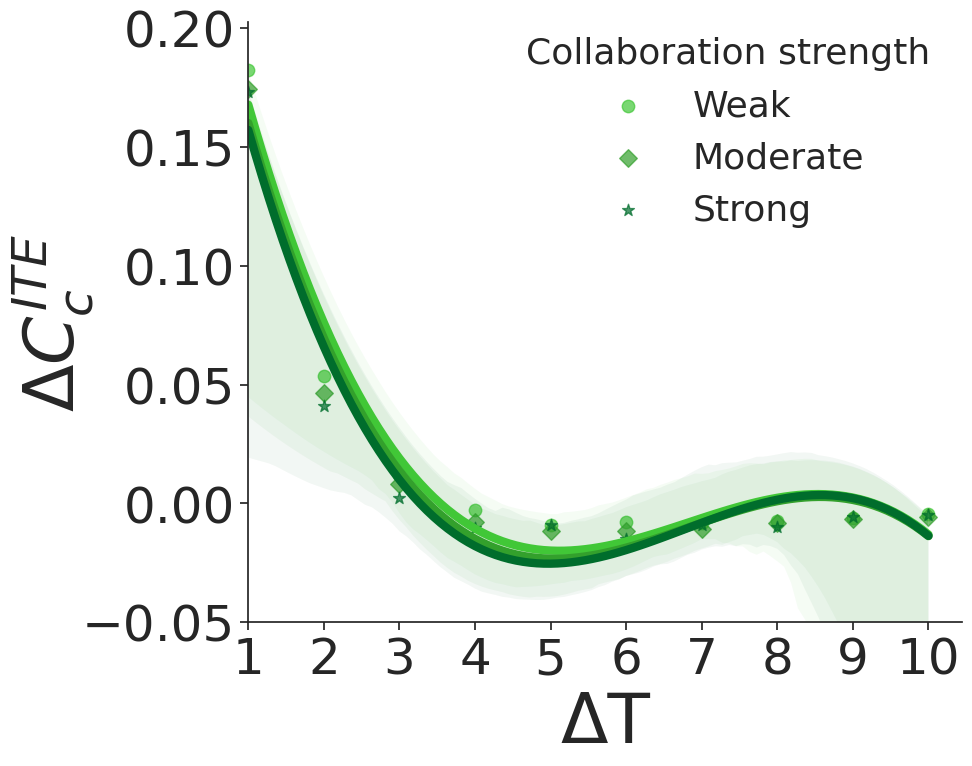

In [14]:
sns.set(style="ticks", font_scale=1.5)
palette = {'Weak': '#41C737','Moderate': '#33A02C','Strong': '#006D2C'}
g = sns.lmplot(data=data21,
    x="delta_T",y="delta_C_coauthor",hue="strength_group",         
    ci=95,order=3,height=8,aspect=1,palette=palette,markers=["o", "D", "*"],
    scatter_kws={"s": 80, "alpha": 0.7},line_kws={"linewidth": 6})
for ax in g.axes.flat:
    for coll in ax.collections:
        if isinstance(coll, PolyCollection):
            coll.set_alpha(0.05) 
plt.ylim(-0.05,None)
plt.xlim(1, None)
plt.xticks(range(1, 11))
ax = g.ax
ax.set_xlabel("ΔT", fontsize=50)
ax.set_ylabel(r"$\Delta C^{ITE}_{c}$", fontsize=50, labelpad=-10)
ax.tick_params(axis='x', labelsize=36)
ax.tick_params(axis='y', labelsize=36)
ymin, ymax = ax.get_ylim()
ax.set_yticks(np.arange(round(ymin, 2), round(ymax + 0.05, 2), 0.05))
if g._legend is not None:
    g._legend.remove()
ax.legend(title="Collaboration strength",loc='upper right', bbox_to_anchor=(1, 1.03),    
    frameon=False,fontsize=26,title_fontsize=26)
plt.tight_layout()
plt.show()

In [15]:
### Fig.5(E)
data22 = pd.read_pickle('G_ripple_data22.pkl')
data22.head(2)

,strength_group,Award age,delta_C_coauthor,group
1,Weak,25,0.121975,Coauthor
2,Weak,26,-0.001466,Coauthor


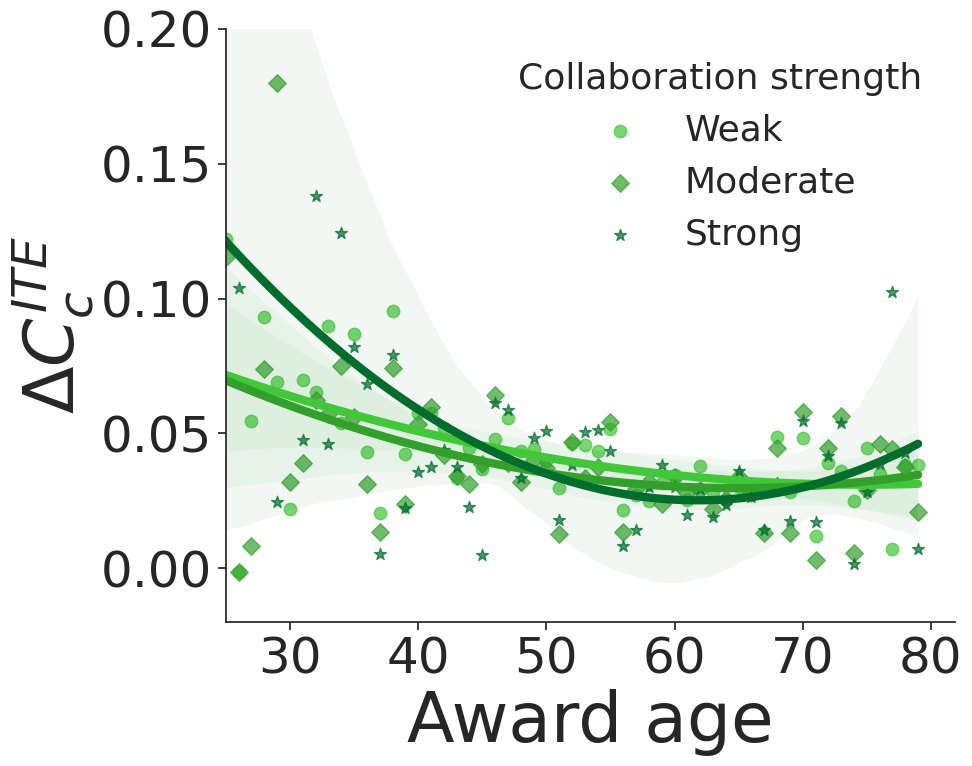

In [16]:
sns.set(style="ticks", font_scale=1.5)
palette = {'Weak': '#41C737','Moderate': '#33A02C','Strong': '#006D2C'}
g = sns.lmplot(data=data22,
    x="Award age",y="delta_C_coauthor",hue="strength_group",         
    ci=95,order=2,height=8,aspect=1,palette=palette,markers=["o", "D", "*"],
    scatter_kws={"s": 80, "alpha": 0.7},line_kws={"linewidth": 6})
for ax in g.axes.flat:
    for coll in ax.collections:
        if isinstance(coll, PolyCollection):
            coll.set_alpha(0.05)
plt.ylim(-0.02,0.2)
plt.xlabel("Award age", fontsize=50)
plt.ylabel(r"$\Delta C^{ITE}_{c}$", fontsize=50)
plt.xlim(25, None)
plt.xticks(range(30, 81,10),fontsize=36)
yticks = np.arange(0.00, 0.201, 0.05)
plt.yticks(yticks, [f"{y:.2f}" for y in yticks], fontsize=36)
if g._legend is not None:
    g._legend.remove()
plt.legend(title="Collaboration strength",loc='upper right',     
    frameon=False,fontsize=26,title_fontsize=26)
plt.tight_layout()
plt.show()

In [17]:
### Fig.5(F)
data23 = pd.read_pickle('G_ripple_data23.pkl')
data23.head(2)

,matched_group,delta_C_coauthor,AuthorID,WinnerID,genderLabel,strength_group
0,M1,0.345092,C118304,W2363,male,Strong
1,M2,0.863965,C151594,W431,male,Moderate


In [18]:
aggregations = {
    'mean': ('delta_C_coauthor', np.mean),
    '95% CI': ('delta_C_coauthor', lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))}
result1 = data23.groupby(["genderLabel", "strength_group"]).agg(**aggregations)
result1.reset_index(inplace=True)
result1

/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1767964/128388402.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result1 = data23.groupby(["genderLabel", "strength_group"]).agg(**aggregations)
/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1767964/128388402.py:4: FutureWarning: The provided callable <function mean at 0x150f4d6ac860> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result1 = data23.groupby(["genderLabel", "strength_group"]).agg(**aggregations)


,genderLabel,strength_group,mean,95% CI
0,female,Weak,0.041170,0.002090
1,female,Moderate,0.033151,0.002398
2,female,Strong,0.030532,0.003253
3,male,Weak,0.032284,0.000844
4,male,Moderate,0.028580,0.000987
5,male,Strong,0.027626,0.001278


In [19]:
result = pd.DataFrame({
    "genderLabel": ["Female", "Female", "Female", "Male", "Male", "Male"],
    "strength_group": ["Weak", "Moderate", "Strong", "Weak", "Moderate", "Strong"],
    "mean": [0.041170, 0.033151, 0.030532, 0.032284, 0.028580, 0.027626],
    "CI": [0.002090, 0.002398, 0.003253, 0.000844, 0.000987, 0.001278]})

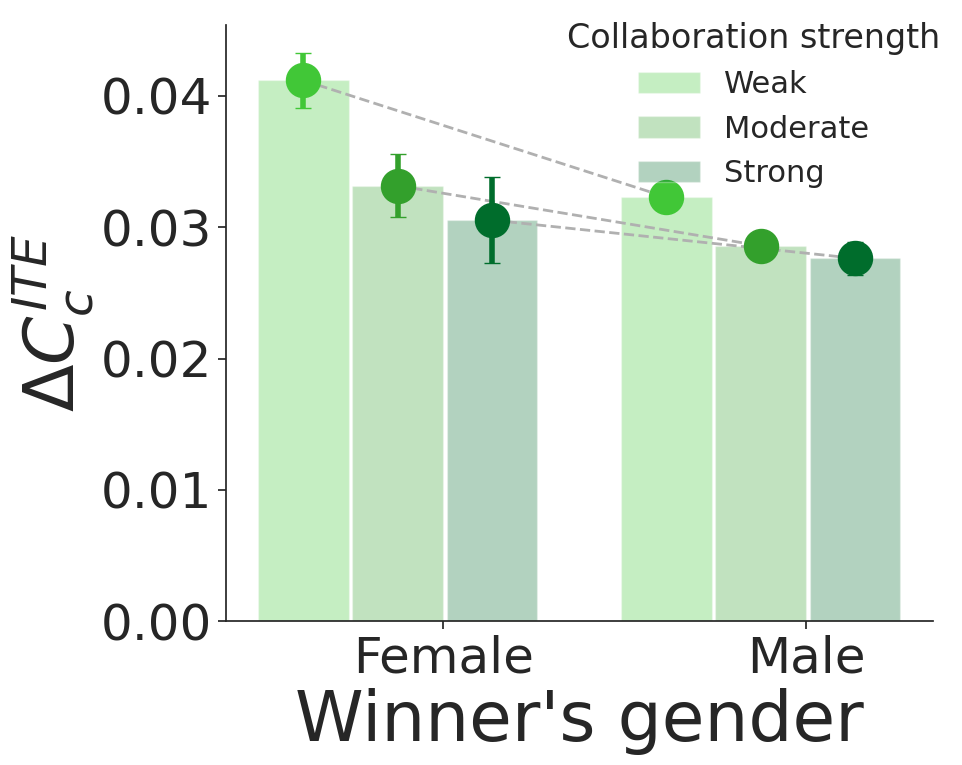

In [20]:
bar_width = 0.25
gap_width = 0.05
x = np.arange(2)
tick_label = ["Female", "Male"]
palette = {'Weak': '#41C737','Moderate': '#33A02C','Strong': '#006D2C'}
fig, ax = plt.subplots(figsize=(10, 8))
for i, tie in enumerate(["Weak", "Moderate", "Strong"]):
    subset = result[result["strength_group"] == tie]
    x_positions = x + i * (bar_width + 0.01)
    ax.bar(x_positions, subset["mean"], width=bar_width,
           color=palette[tie], label=tie, alpha=0.3)
    ax.scatter(x_positions, subset["mean"], s=600,
               edgecolors=palette[tie], facecolors=palette[tie], zorder=3)
    ax.errorbar(x_positions, subset["mean"], yerr=subset["CI"],
                color=palette[tie], capsize=6, elinewidth=4,linestyle='none')
    ax.plot(x_positions, subset["mean"], linestyle="--", color="#B0B0B0", linewidth=2, zorder=1)

ax.set_xlabel("Winner's gender", fontsize=50)
ax.set_ylabel(r"$\Delta C^{ITE}_{c}$", fontsize=50)
ax.set_xticks(x + (1.5 * bar_width + 0.01))
ax.set_xticklabels(tick_label, fontsize=36)
ax.tick_params(axis="y", labelsize=36)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
legend = ax.legend(title="Collaboration strength", fontsize=22, title_fontsize=24,
                   loc="upper right", bbox_to_anchor=(1.05, 1.05),
                   frameon=False)
plt.tight_layout()
plt.show()

In [21]:
### Fig.5(G)
data24 = pd.read_pickle('G_ripple_data24.pkl')
data24.head(2)

,matched_group,delta_C_coauthor,AuthorID,WinnerID,awardLabel,award_prestige,prestige_group,is_top5,strength_group
0,M1,0.345092,C112938,W2273,Fellow of the Royal Society,33630.6,High,1,Strong
1,M147,0.074300,C102506,W2273,Fellow of the Royal Society,33630.6,High,1,Moderate


In [22]:
aggregations = {
    'mean': ('delta_C_coauthor', np.mean),
    '95% CI': ('delta_C_coauthor', lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))}
result1 = data24.groupby(["prestige_group", "strength_group"]).agg(**aggregations)
result1.reset_index(inplace=True)
result1

/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1767964/2138397188.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result1 = data24.groupby(["prestige_group", "strength_group"]).agg(**aggregations)
/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1767964/2138397188.py:4: FutureWarning: The provided callable <function mean at 0x150f4d6ac860> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result1 = data24.groupby(["prestige_group", "strength_group"]).agg(**aggregations)


,prestige_group,strength_group,mean,95% CI
0,Low,Weak,0.036427,0.001145
1,Low,Moderate,0.031385,0.001336
2,Low,Strong,0.028122,0.001715
3,High,Weak,0.030134,0.001116
4,High,Moderate,0.027614,0.001291
5,High,Strong,0.027550,0.001700


In [23]:
result = pd.DataFrame({
    "prestige_group": ["Low", "Low", "Low", "High", "High", "High"],
    "strength_group": ["Weak", "Moderate", "Strong","Weak", "Moderate", "Strong"],
    "mean": [0.036427, 0.031385, 0.028122,0.030134, 0.027614, 0.027550],
    "CI": [0.001145, 0.001336, 0.001715,0.001116, 0.001291, 0.001700]})

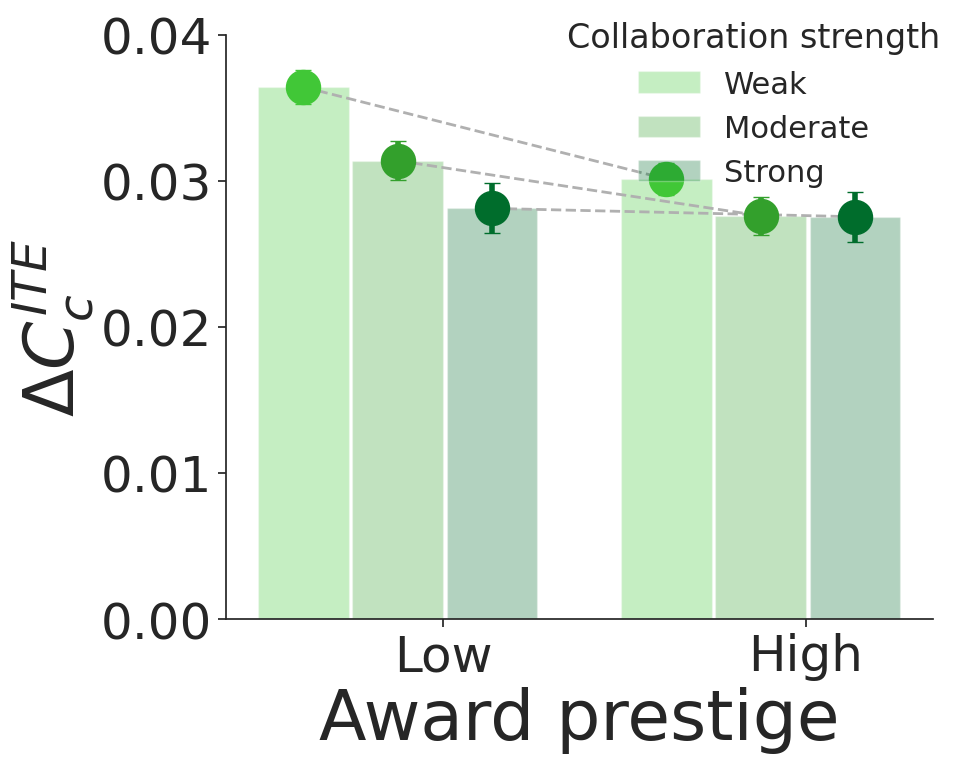

In [24]:
bar_width = 0.25
gap_width = 0.05
x = np.arange(2)  
tick_label = ["Low", "High"]
palette = {'Weak': '#41C737','Moderate': '#33A02C','Strong': '#006D2C'}
fig, ax = plt.subplots(figsize=(10, 8))

for i, tie in enumerate(["Weak", "Moderate", "Strong"]):
    subset = result[result["strength_group"] == tie].sort_values(
        "prestige_group", key=lambda c: c.map({"Low": 0, "High": 1}))
    x_positions = x + i * (bar_width + 0.01)
    ax.bar(x_positions, subset["mean"], width=bar_width,
           color=palette[tie], label=tie, alpha=0.3, zorder=1)    
    ax.scatter(x_positions, subset["mean"], s=600,
               edgecolors=palette[tie], facecolors=palette[tie], zorder=3)
    ax.errorbar(x_positions, subset["mean"], yerr=subset["CI"],
                color=palette[tie], capsize=6, elinewidth=4, linestyle='none', zorder=3)
    ax.plot(x_positions, subset["mean"], linestyle="--",color="#B0B0B0", linewidth=2, zorder=1)

ax.set_xlabel("Award prestige", fontsize=50)
ax.set_ylabel(r"$\Delta C^{ITE}_{c}$", fontsize=50)
ax.set_xticks(x + (1.5 * bar_width + 0.01))
ax.set_xticklabels(tick_label, fontsize=36)
ax.tick_params(axis="y", labelsize=36)
ax.set_ylim(0, 0.04)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
legend = ax.legend(title="Collaboration strength", fontsize=22, title_fontsize=24,
                   loc="upper right", bbox_to_anchor=(1.05, 1.07),
                   frameon=False)
plt.tight_layout()
plt.show()

In [25]:
### Fig.5(H)
aggregations = {'mean': ('delta_C_coauthor', np.mean),
    '95% CI': ('delta_C_coauthor', lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))}
result1 = data24.groupby(["is_top5", "strength_group"]).agg(**aggregations)
result1.reset_index(inplace=True)
result1

/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1767964/1479747534.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result1 = data24.groupby(["is_top5", "strength_group"]).agg(**aggregations)
/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1767964/1479747534.py:4: FutureWarning: The provided callable <function mean at 0x150f4d6ac860> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result1 = data24.groupby(["is_top5", "strength_group"]).agg(**aggregations)


,is_top5,strength_group,mean,95% CI
0,0,Weak,0.033641,0.000926
1,0,Moderate,0.029732,0.001075
2,0,Strong,0.028044,0.001386
3,1,Weak,0.032438,0.001589
4,1,Moderate,0.028840,0.001848
5,1,Strong,0.027182,0.002465


In [26]:
result = pd.DataFrame({"is_top5": [0, 0, 0, 1, 1, 1],
    "strength_group": ["Weak", "Moderate", "Strong","Weak", "Moderate", "Strong"],
    "mean": [0.033641, 0.029732, 0.028044,0.032438, 0.028840, 0.027182],
    "CI": [0.000926, 0.001075, 0.001386,0.001589, 0.001848, 0.002465]})

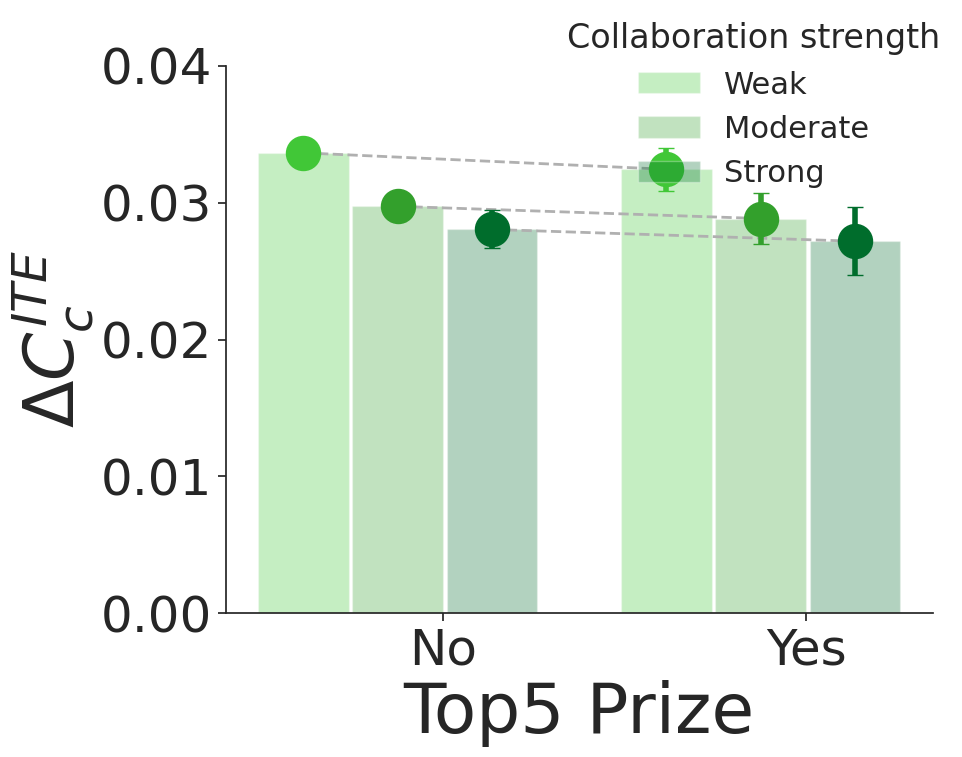

In [27]:
bar_width = 0.25
gap_width = 0.05
x = np.arange(2)  
tick_label = ["No", "Yes"]
palette = {'Weak': '#41C737','Moderate': '#33A02C','Strong': '#006D2C'}
fig, ax = plt.subplots(figsize=(10, 8))

for i, tie in enumerate(["Weak", "Moderate", "Strong"]):
    subset = (result[result["strength_group"] == tie].sort_values("is_top5", ascending=True))
    x_positions = x + i * (bar_width + 0.01)
    ax.bar(x_positions, subset["mean"], width=bar_width,
           color=palette[tie], label=tie, alpha=0.3, zorder=1)    
    ax.scatter(x_positions, subset["mean"], s=600,
               edgecolors=palette[tie], facecolors=palette[tie], zorder=3)
    ax.errorbar(x_positions, subset["mean"], yerr=subset["CI"],
                color=palette[tie], capsize=6, elinewidth=4, linestyle='none', zorder=3)
    ax.plot(x_positions, subset["mean"], linestyle="--",color="#B0B0B0", linewidth=2, zorder=1)

ax.set_xlabel("Top5 Prize", fontsize=50)
ax.set_ylabel(r"$\Delta C^{ITE}_{c}$", fontsize=50)
ax.set_xticks(x + (1.5 * bar_width + 0.01))
ax.set_xticklabels(tick_label, fontsize=36)
ax.tick_params(axis="y", labelsize=36)
ax.set_ylim(0, 0.04)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
legend = ax.legend(title="Collaboration strength", fontsize=22, title_fontsize=24,
                   loc="upper right", bbox_to_anchor=(1.05, 1.13),
                   frameon=False)
plt.tight_layout()
plt.show()